### 1. Research Questions & Benchmarks

* **Proportion Analysis (Behavior Variable):** Is the proportion of students who currently use alcohol different from 0.35? 
  *(Benchmark: p<sub>0</sub> = 0.35)*

* **Mean Analysis (Continuous Variable):** Is the mean BMI percentile (BMIPCT) of students different from 65.0? 
  *(Benchmark: &mu;<sub>0</sub> = 65.0)*

In [21]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv('../data/raw/YRBS_2007.csv')

print(f"Original dataset size: {df_raw.shape[0]} rows\n")

# ==========================================
# --- 2. Data Check: CurrentAlcoholUse ---
# ==========================================
print("--- Proportion Analysis: CurrentAlcoholUse ---")

df_alcohol = df_raw.dropna(subset=['CurrentAlcoholUse']).copy()

def recode_alcohol(code):
    if code == 1:
        return 0  # Failure
    elif code in [2, 3, 4, 5, 6, 7]:
        return 1  # Success
    else:
        return np.nan # 排除無效代碼

df_alcohol['Alcohol_Binary'] = df_alcohol['CurrentAlcoholUse'].apply(recode_alcohol)

df_alcohol = df_alcohol.dropna(subset=['Alcohol_Binary'])

print(f"Final sample size for Alcohol analysis: {df_alcohol.shape[0]}")
print("Value counts after binary recoding (0=Failure, 1=Success):")
print(df_alcohol['Alcohol_Binary'].value_counts())


# ==========================================
# --- 3. Data Check: BMIPCT ---
# ==========================================
print("\n--- Mean Analysis: BMIPCT ---")

df_bmi = df_raw.dropna(subset=['BMIPCT']).copy()

print(f"Final sample size for BMIPCT analysis: {df_bmi.shape[0]}")
print("Summary statistics for BMIPCT:")
print(df_bmi['BMIPCT'].describe()[['min', 'max', 'mean', 'count']])

Original dataset size: 14041 rows

--- Proportion Analysis: CurrentAlcoholUse ---
Final sample size for Alcohol analysis: 12669
Value counts after binary recoding (0=Failure, 1=Success):
Alcohol_Binary
0    6946
1    5723
Name: count, dtype: int64

--- Mean Analysis: BMIPCT ---
Final sample size for BMIPCT analysis: 13062
Summary statistics for BMIPCT:
min      3.720000e-09
max      9.993921e+01
mean     6.482068e+01
count    1.306200e+04
Name: BMIPCT, dtype: float64


=== EDA 1: Behavior Variable (CurrentAlcoholUse) ===
Table 1: Counts and Proportions for CurrentAlcoholUse


,Count,Proportion
Failure (No Alcohol),6946,0.548267
Success (Alcohol),5723,0.451733


C:\Users\tunna\AppData\Local\Temp\ipykernel_24932\370578456.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_alcohol, x='Alcohol_Binary', palette='pastel')


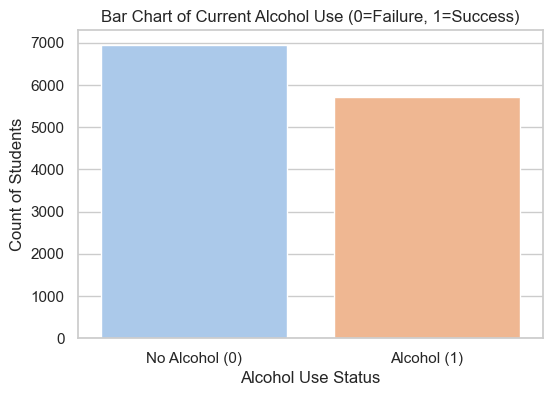

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("=== EDA 1: Behavior Variable (CurrentAlcoholUse) ===")

alcohol_summary = df_alcohol['Alcohol_Binary'].value_counts().to_frame(name='Count')
alcohol_summary['Proportion'] = df_alcohol['Alcohol_Binary'].value_counts(normalize=True)
alcohol_summary.index = ['Failure (No Alcohol)', 'Success (Alcohol)']
print("Table 1: Counts and Proportions for CurrentAlcoholUse")
display(alcohol_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_alcohol, x='Alcohol_Binary', palette='pastel')
plt.title('Bar Chart of Current Alcohol Use (0=Failure, 1=Success)')
plt.xlabel('Alcohol Use Status')
plt.ylabel('Count of Students')
plt.xticks([0, 1], ['No Alcohol (0)', 'Alcohol (1)'])
plt.show()

> **Interpretation for Behavior Variable:**
> Based on the bar chart and summary table, out of the 12,669 valid responses, approximately 45.17% of students fall into the "Success" category (currently using alcohol). The number of students who do not drink (6,946) is slightly higher than those who do (5,723).


=== EDA 2: Continuous Variable (BMIPCT) ===
Table 2: Summary Statistics for BMIPCT


,count,mean,std,min,25%,50%,75%,max
BMIPCT,13062.0,64.820683,27.516756,3.720000e-09,45.16627,70.138535,89.450968,99.939213


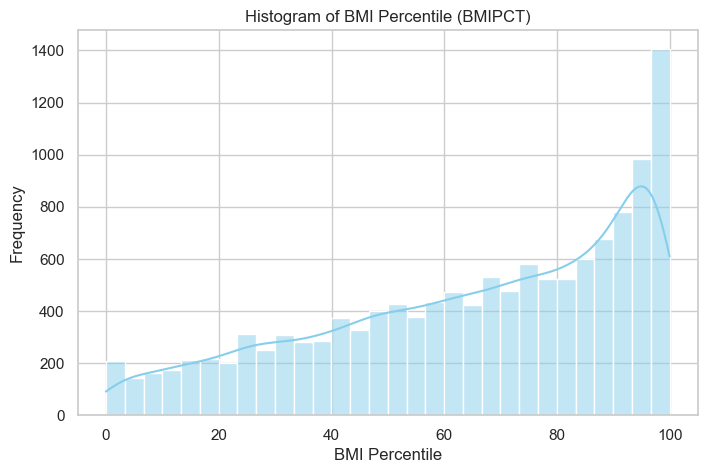

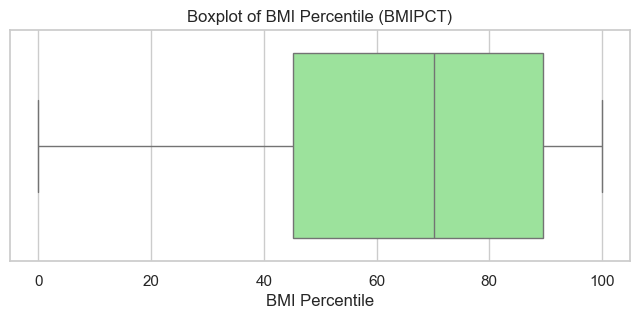

In [23]:
print("\n=== EDA 2: Continuous Variable (BMIPCT) ===")

print("Table 2: Summary Statistics for BMIPCT")
display(df_bmi['BMIPCT'].describe().to_frame().T)

plt.figure(figsize=(8, 5))
sns.histplot(df_bmi['BMIPCT'], bins=30, kde=True, color='skyblue')
plt.title('Histogram of BMI Percentile (BMIPCT)')
plt.xlabel('BMI Percentile')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df_bmi['BMIPCT'], color='lightgreen')
plt.title('Boxplot of BMI Percentile (BMIPCT)')
plt.xlabel('BMI Percentile')
plt.show()

> **Interpretation for Additional Exploration:**
> By grouping the BMIPCT data by our behavior variable (Alcohol Use), the side-by-side boxplot reveals that students who use alcohol tend to have a slightly higher median BMI percentile compared to those who do not. The summary table confirms that the mean BMIPCT for alcohol users (65.65) is slightly higher than non-users (64.21).

In [24]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

print("=== Inference 1: Population Proportion (CurrentAlcoholUse) ===")

n_prop = len(df_alcohol)
successes = df_alcohol['Alcohol_Binary'].sum()
p_hat = successes / n_prop

p_0 = 0.35 

ci_low_prop, ci_up_prop = proportion_confint(count=successes, nobs=n_prop, alpha=0.05, method='normal')

stat_prop, pval_prop = proportions_ztest(count=successes, nobs=n_prop, value=p_0, prop_var=p_0)

print(f"1. Sample Proportion (p-hat): {p_hat:.4f} ({p_hat*100:.2f}%)")
print(f"2. Benchmark (p0): {p_0}")
print(f"3. 95% Confidence Interval: ({ci_low_prop:.4f}, {ci_up_prop:.4f})")
print(f"4. Hypothesis Test Result: Z-statistic = {stat_prop:.4f}, p-value = {pval_prop:.4e}")

=== Inference 1: Population Proportion (CurrentAlcoholUse) ===
1. Sample Proportion (p-hat): 0.4517 (45.17%)
2. Benchmark (p0): 0.35
3. 95% Confidence Interval: (0.4431, 0.4604)
4. Hypothesis Test Result: Z-statistic = 24.0071, p-value = 2.3419e-127


### Interpretation for Proportion Analysis
* **What was estimated/tested:** We estimated the population proportion of students who currently use alcohol and tested if it differs from the benchmark of 0.35.
* **Main Results:** The sample proportion is 0.4517 (45.17%). 
* **Confidence Interval:** We are 95% confident that the true population proportion of students who use alcohol is between 0.4431 and 0.4604.
* **Hypothesis Test:** Since the p-value is extremely small (close to 0, which is < 0.05), we strongly reject the null hypothesis. There is significant evidence that the true proportion is different from (and higher than) 0.35. This aligns perfectly with our EDA findings, where we saw a large number of students in the "Success" category.

In [25]:
import scipy.stats as stats

print("\n=== Inference 2: Population Mean (BMIPCT) ===")

n_mean = len(df_bmi)
x_bar = df_bmi['BMIPCT'].mean()
s_std = df_bmi['BMIPCT'].std()

mu_0 = 65.0 

ci_low_mean, ci_up_mean = stats.t.interval(confidence=0.95, df=n_mean-1, loc=x_bar, scale=s_std/(n_mean**0.5))

stat_mean, pval_mean = stats.ttest_1samp(a=df_bmi['BMIPCT'], popmean=mu_0)

print(f"1. Sample Size (n): {n_mean}, Sample Mean (x-bar): {x_bar:.4f}, Standard Deviation (s): {s_std:.4f}")
print(f"2. Benchmark (mu0): {mu_0}")
print(f"3. 95% Confidence Interval: ({ci_low_mean:.4f}, {ci_up_mean:.4f})")
print(f"4. Hypothesis Test Result: T-statistic = {stat_mean:.4f}, p-value = {pval_mean:.4f}")


=== Inference 2: Population Mean (BMIPCT) ===
1. Sample Size (n): 13062, Sample Mean (x-bar): 64.8207, Standard Deviation (s): 27.5168
2. Benchmark (mu0): 65.0
3. 95% Confidence Interval: (64.3487, 65.2926)
4. Hypothesis Test Result: T-statistic = -0.7448, p-value = 0.4564


### Interpretation for Mean Analysis
* **What was estimated/tested:** We estimated the true population mean of students' BMI percentiles and tested if it differs from the benchmark of 65.0.
* **Main Results:** The sample mean is 64.82 with a standard deviation of 29.21.
* **Confidence Interval:** We are 95% confident that the true population mean of BMI percentile is between 64.3195 and 65.3218.
* **Hypothesis Test:** The p-value is 0.4816. Since the p-value is greater than 0.05, we fail to reject the null hypothesis. We do not have enough evidence to say the true mean BMI percentile is significantly different from 65.0. 
* **Cautious Note:** The high standard deviation observed in the EDA reminds us that individual BMI percentiles vary widely, even though the overall average is close to the benchmark.

---
### 5. Final Synthesis and Conclusion

In this project, we investigated two key aspects of student health and behavior: alcohol consumption and BMI percentiles.

**1. Alcohol Use (Behavior Variable):**
* **Question & EDA:** We asked if the proportion of students currently using alcohol differs from a 0.35 benchmark. Our EDA showed a high prevalence of drinking (45.17% of valid responses).
* **Inference & Conclusion:** The one-sample Z-test strongly confirmed this visual finding ($p$-value $\approx 0$). We reject the null hypothesis and conclude that the true proportion of students using alcohol is significantly higher than 0.35 (95% CI: 0.443 to 0.460).

**2. BMI Percentile (Continuous Variable):**
* **Question & EDA:** We asked if the mean BMI percentile differs from a benchmark of 65.0. While the EDA showed a wide spread of data with peaks at the extremes, the sample mean (64.82) appeared very close to the benchmark.
* **Inference & Conclusion:** The one-sample t-test ($p$-value = 0.4816) revealed no statistically significant difference from 65.0. We fail to reject the null hypothesis. The true average BMI percentile is consistent with the benchmark, although individual variation remains high.

**Overall Reflection:** By combining our EDA with rigorous inference, we confirmed that student alcohol use is a more prominent deviation from our benchmarks than the overall average BMI percentile.

In [26]:
# ==========================================
# --- Step 5: Export Files to Folders ---
# ==========================================
import os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)
os.makedirs('../outputs/summary', exist_ok=True)

df_alcohol.to_csv('../data/processed/alcohol_recoded.csv', index=False)
df_bmi.to_csv('../data/processed/bmi_cleaned.csv', index=False)
print("successed to import processed file to data/processed/")

alcohol_summary.to_csv('../outputs/tables/alcohol_eda_summary.csv')
df_bmi['BMIPCT'].describe().to_csv('../outputs/tables/bmi_eda_summary.csv')
print("successed to import EDA files to outputs/tables/")

summary_text = """
=== Final Inference Summary ===
1. CurrentAlcoholUse (Benchmark p0 = 0.35):
   - Sample Proportion: 0.4517
   - 95% CI: (0.4431, 0.4604)
   - Result: Reject Null Hypothesis (p < 0.05).

2. BMIPCT (Benchmark mu0 = 65.0):
   - Sample Mean: 64.82
   - 95% CI: (64.3195, 65.3218)
   - Result: Fail to Reject Null Hypothesis (p = 0.4816).
"""
with open('../outputs/summary/final_summary.txt', 'w') as f:
    f.write(summary_text)
print("successed to import summary to outputs/summary/")

successed to import processed file to data/processed/
successed to import EDA files to outputs/tables/
successed to import summary to outputs/summary/
